# Vizualizace

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Z minule lekce
food_sample_100 = pd.read_csv("https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/nacteni-dat/nacteni-dat/food_sample_100.csv")
food_other = pd.read_csv("https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/spojovani/sjednoceni-dat/food_other.csv")
food_nutrient = pd.read_csv("https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/podmineny-vyber/podmineny-vyber/food_nutrient.csv")
branded_food = pd.read_csv("https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/spojovani/excs/znacky/branded_food.csv")

food = pd.concat([food_sample_100, food_other])
food_brands = pd.merge(food, branded_food, on="fdc_id")

In [3]:
food_brands["branded_food_category"] = food_brands["branded_food_category"].replace(
    {
        "Candy": "Cukrovinky",
        "Popcorn, Peanuts, Seeds & Related Snacks": "Slané snacky",
        "Cheese": "Sýry",
        "Ice Cream & Frozen Yogurt": "Zmrzlina",
        "Chips, Pretzels & Snacks": "Chipsy",
        "Cookies & Biscuits": "Sušenky",
        "Pickles, Olives, Peppers & Relishes": "Nakl. zelenina",
        "Breads & Buns": "Pečivo",
        "Fruit & Vegetable Juice, Nectars & Fruit Drinks": "Džusy",
        "Snack, Energy & Granola Bars": "En. tyčinky",
        "Chocolate": "Čokoláda",
        "Other Snacks": "Další snacky",
    }
)

In [5]:
food_merged_brands = pd.merge(food_brands, food_nutrient, on="fdc_id")
food_merged_brands = food_merged_brands.rename(columns={"name": "nutrient_name"})
food_merged_brands["nutrient_name"] = food_merged_brands["nutrient_name"].replace({"Total lipid (fat)": "Lipid (tuk)"})

food_list = [
    "Cukrovinky",
    "Slané snacky",
    "Sýry",
    "Zmrzlina",
    "Chipsy",
    "Sušenky",
    "Nakl. zelenina",
    "Pečivo",
    "Džusy",
    "En. tyčinky",
    "Čokoláda",
    "Další snacky",
]

In [6]:
# Filtrace záznamů v food_brands, kde sloupec 'branded_food_category' obsahuje hodnoty ze seznamu food_list
food_top_cat = food_brands[food_brands["branded_food_category"].isin(
    food_list)]

# Spojení vyfiltrovaného food_top_cat s food_nutrient na základě sloupce 'fdc_id'
food_brands_nut = pd.merge(food_top_cat, food_nutrient, on="fdc_id")

# Filtrace záznamů, kde 'nutrient_name' má hodnotu 'Protein'
food_merged_brands_protein = food_merged_brands[food_merged_brands["nutrient_name"] == "Protein"]

# Filtrace záznamů, kde 'nutrient_name' je buď 'Protein' nebo 'Lipid (tuk)', a kde 'branded_food_category' má hodnotu 'En. tyčinky'
food_merged_brands_box = food_merged_brands[
    (food_merged_brands["nutrient_name"].isin(["Protein", "Lipid (tuk)"]))
    & (food_merged_brands["branded_food_category"] == "En. tyčinky")
]

In [7]:
food_top_cat[["fdc_id", "description", "branded_food_category"]]

,fdc_id,description,branded_food_category
2,1107295,"ORIGINAL ROUNDS TORTILLA CHIPS, ORIGINAL",Chipsy
3,1107475,"NACHO QUESO SUPREME DIP, NACHO QUESO SUPREME",Sýry
13,1109393,"HOMESTYLE PARMESAN-ROMANO GRATED CHEESE, HOMES...",Sýry
14,1109400,"WHITE CHUNK MACADAMIA SOFT BAKED COOKIES, WHIT...",Sušenky
15,1109434,"DRY ROASTED PEANUTS, DRY ROASTED",Slané snacky
...,...,...,...
9526,2659382,SRIRACHA & SCALLION BAGEL SHOP STYLE CREAM CHE...,Sýry
9530,2660573,"CUCUMBER DILL GOAT CHEESE DIP, CUCUMBER DILL G...",Sýry
9531,2660613,"DARK CHOCOLATE HIMALAYAN SALTED ALMONDS, DARK ...",Slané snacky
9535,2661380,PRETZEL MINI TWISTS,Chipsy


## Countplot

<Axes: xlabel='branded_food_category', ylabel='count'>

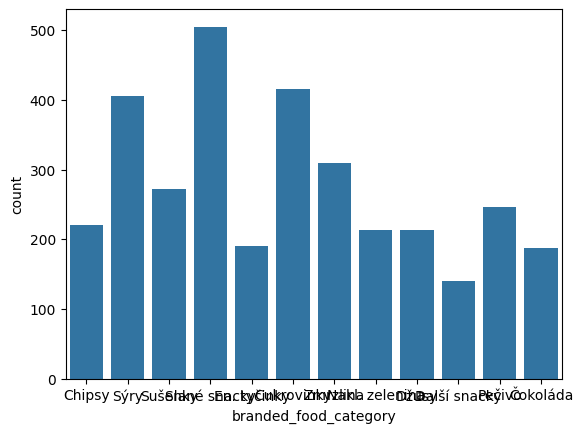

In [8]:
sns.countplot(food_top_cat, x="branded_food_category")

[Text(0.5, 1.0, 'Pocty potravin v kategoriich'),
 Text(0, 0.5, 'Popisek Y'),
 Text(0.5, 0, 'Popisek X')]

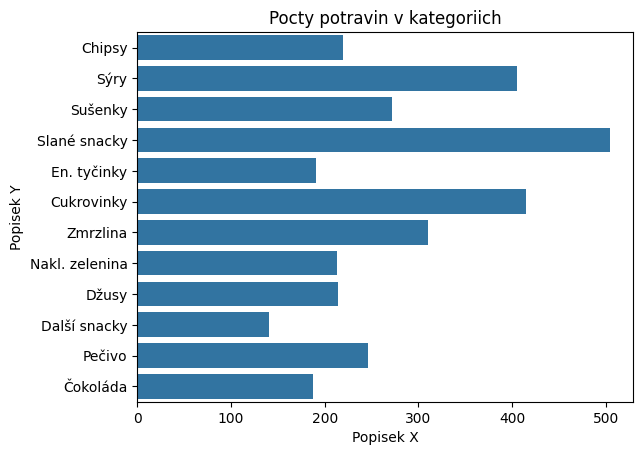

In [9]:
ax = sns.countplot(food_top_cat, y="branded_food_category")

# ax.tick_params(axis="x", rotation=45)

ax.set(title="Pocty potravin v kategoriich", 
       ylabel="Popisek Y",
       xlabel="Popisek X",
)

## Histogram

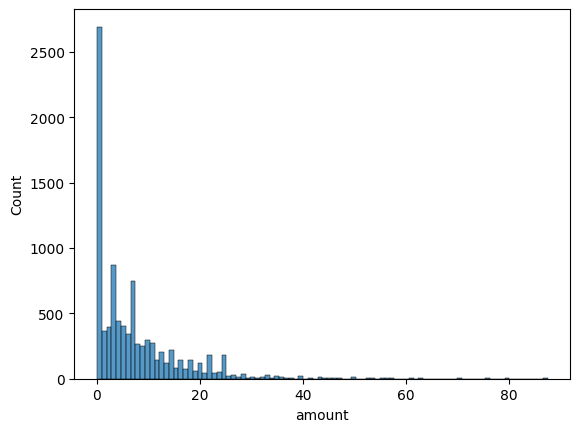

In [10]:
ax = sns.histplot(food_merged_brands_protein, x="amount")

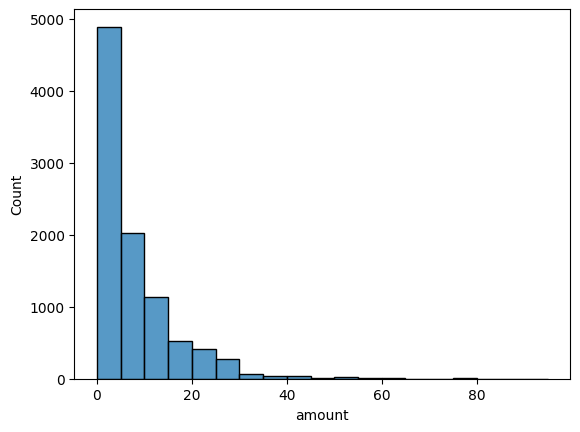

In [11]:
ax = sns.histplot(food_merged_brands_protein, 
                  x="amount",
                  bins=list(range(0, 100, 5)))

[Text(0.5, 1.0, 'Histogram')]

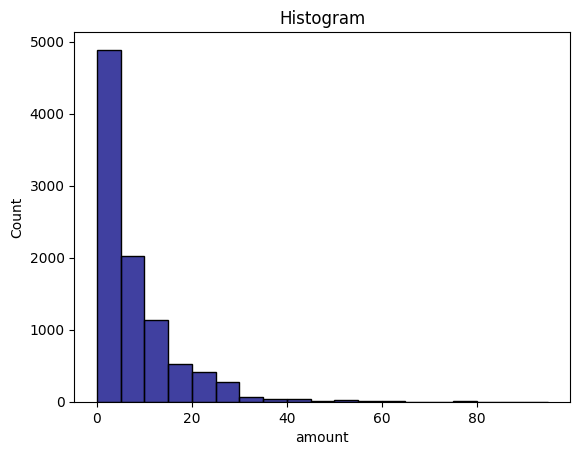

In [12]:
ax = sns.histplot(food_merged_brands_protein, 
                  x="amount",
                  bins=range(0, 100, 5),
                  color="navy")

ax.set(title="Histogram")

In [13]:
import matplotlib.pyplot as plt

In [14]:
plt.figure(figsize=(12, 3))

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

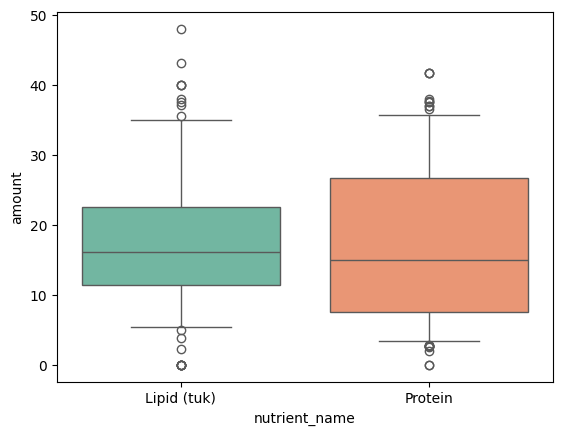

In [15]:
ax = sns.boxplot(food_merged_brands_box,
                 x="nutrient_name", 
                 y="amount", 
                 whis=[5, 95],
                #  color="blue",
                palette="Set2",
                hue="nutrient_name"
                 )

In [16]:
palette={"Lipid (tuk)": "orange", "Protein": "green"},

In [17]:
sns.set_theme(style="darkgrid")

## Cvičení

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

food_nutrient = pd.read_csv("food_nutrient.csv")
branded_food = pd.read_csv("branded_food.csv")
food_sample_100 = pd.read_csv("food_sample_100.csv")
food_other = pd.read_csv("food_other.csv")
food = pd.concat([food_sample_100, food_other])
food_brands = pd.merge(food, branded_food, on="fdc_id")

top_cat_list = ['Candy', 'Popcorn, Peanuts, Seeds & Related Snacks', 'Cheese', 'Ice Cream & Frozen Yogurt', 'Chips, Pretzels & Snacks', 'Cookies & Biscuits', 'Pickles, Olives, Peppers & Relishes', 'Breads & Buns', 'Fruit & Vegetable Juice, Nectars & Fruit Drinks', 'Snack, Energy & Granola Bars', 'Chocolate', 'Other Snacks']
food_brands = food_brands[food_brands["branded_food_category"].isin(top_cat_list)]
food_brands["branded_food_category"] = food_brands["branded_food_category"].replace({
    "Candy": "Cukrovinky",
    "Popcorn, Peanuts, Seeds & Related Snacks": "Slané snacky",
    "Cheese": "Sýry",
    "Ice Cream & Frozen Yogurt": "Zmrzlina",
    "Chips, Pretzels & Snacks": "Chipsy",
    "Cookies & Biscuits": "Sušenky",
    "Pickles, Olives, Peppers & Relishes": "Nakl. zelenina",
    "Breads & Buns": "Pečivo",
    "Fruit & Vegetable Juice, Nectars & Fruit Drinks": "Džusy",
    "Snack, Energy & Granola Bars": "En. tyčinky",
    "Chocolate": "Čokoláda",
    "Other Snacks": "Další snacky"
})

food_merged_brands = pd.merge(food_brands, food_nutrient, on="fdc_id")
food_merged_brands = food_merged_brands.rename(columns={"name": "nutrient_name"})

### Odstín

V rámci lekce jsme porovnávali množství proteinů._

Vytvoř tabulku `food_merged_brands_protein_lipid`, která bude obsahovat data o množství proteinů (`Protein`) a lipidů (`Total lipid (fat)`), tj. z tabulky `food_merged_brands` vyber řádky, které obsahují buď `Protein` nebo `Total lipid (fat)` ve sloupci `nutrient_name`. K vytvoření je nejlepší metoda `isin()`. Pokud si na metodu nepamatuješ, můžeš se inspirovat řádkem [níže](https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/vizualizace/excs/odstin/output_1.png).

Nyní zkus pomocí histogramu porovnat, jestli je v potravinách více proteinů nebo lipidů. Nejprve zkus vytvořit histogram stejným způsobem, jako jsme to dělali v lekci. Dostaneš obrázek podobný tomu níže.

Tento obrázek nám ale neříká, kolik je v potravinách tuků a kolik lipidů, protože obě výživné látky jsou smíchané dohromady. Abys dokázal(a) rozlišit mezi oběma výživnými látkami, použij parametr `hue`, kterému zadáš jako hodnotu `nutrient_name`. [Díky tomu bude mít každá výživná látka samostatný sloupec se svojí barvou](https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/vizualizace/excs/odstin/output_2.png).

<Axes: xlabel='amount', ylabel='Count'>

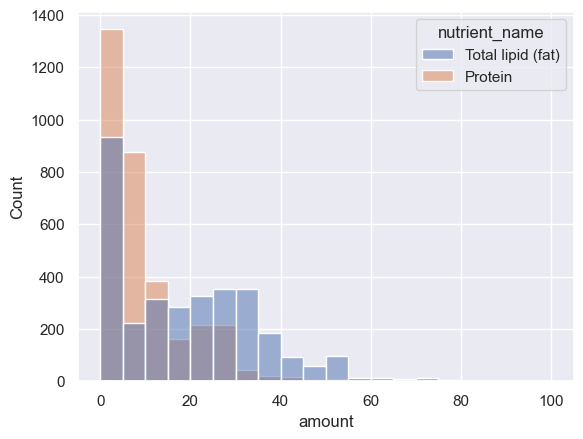

In [20]:
food_merged_brands_protein_lipid = food_merged_brands[
    food_merged_brands["nutrient_name"].isin(["Protein", "Total lipid (fat)"])]
sns.histplot(food_merged_brands_protein_lipid, x="amount", hue="nutrient_name", bins=range(0, 105, 5)) # šírka?

### Catplot

Další zajímavý graf, který `seaborn` umí, je `catplot`. Pomocí něj můžeme porovnat obsat výživných látek pro jednotlivé kategorie potravin. Tvým úkolem bude porovnat obsah proteinů a karbohydrátů pro 12 nejčastějších kategorií.

Vytvoř si pomocí dotazu tabulku, ve které budou informace pouze o proteinech a karbohydrátech. Karbohydráty hledej pod názvem `Carbohydrate, by difference`. Můžeš je přejmenovat na "Karbohydráty" pomocí metody `replace`.

Dále použij funkci `catplot`. Její použití je velmi podobné ostatním funkcím. Jako první parametr zadej tabulku s daty, jako parametr `x` sloupeček s názvem kategorie (`branded_food_category`), jako parametr `y` sloupeček `amount` a jako parametr `hue` sloupeček `nutrition_name`. Alternativně můžeš před vygenerováním grafu sloupeček `nutrition_name` přejmenovat například na `Výživná látka`, protože bude použit jako nadpis legendy.

Nech si zobrazit graf. Jednotlivé tečky představují hodnoty pro jednotlivé potraviny, každá tečka reprezentuje jednu potravinu. Barva tečky určuje, o jakou výživnou látku jde. Dále zkus přidat k volání funkce `catplot` parametr `s` s hodnotou `2` a podívej se, jak se graf změnil. Zkus případně i jiné hodnoty tohoto parametru.

Prohlédni si [graf](https://kodim.cz/cms/assets/czechitas/python-data-1/python-pro-data-1/vizualizace/excs/catplot/output.png) a odpověz na otázky:

1. Pro jakou kategorii platí, že drtivá většina výrobků má více proteinů než karbohydrátů?
2. Pro jakou kategorii platí, že drtivá většina výrobků má více karbohydrátů než proteinů?
3. Existuje nějaká kategorie, kde je na výběr alespoň několik produktů s větším množství karbohydrátů než proteinů, ale i několik produktů s větším množstvím proteinů než karbohydrátů?

C:\Users\Aneta\AppData\Local\Temp\ipykernel_22452\4294344250.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  food_merged_brands_protein_carb["nutrient_name"] = food_merged_brands_protein_carb["nutrient_name"].replace("Carbohydrate, by difference", "Karbohydráty")


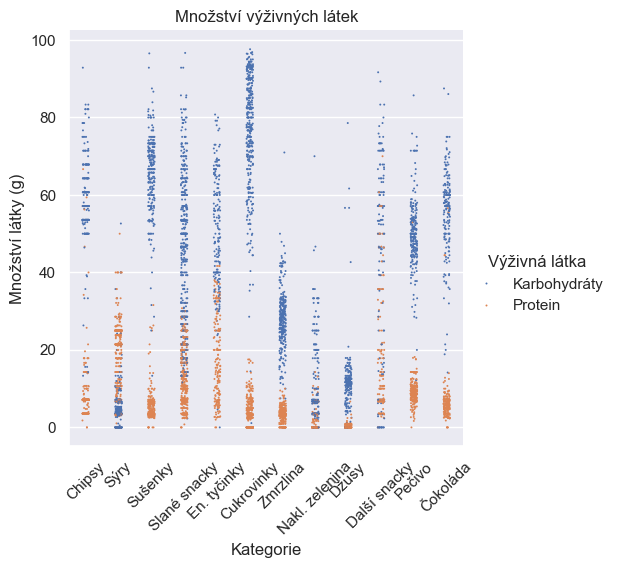

In [21]:
food_merged_brands_protein_carb = food_merged_brands[
    food_merged_brands["nutrient_name"].isin(["Protein", "Carbohydrate, by difference"])]
food_merged_brands_protein_carb["nutrient_name"] = food_merged_brands_protein_carb["nutrient_name"].replace("Carbohydrate, by difference", "Karbohydráty")

ax = sns.catplot(
    data=food_merged_brands_protein_carb,
    x="branded_food_category",
    y="amount",
    hue="nutrient_name",
    s=2,
)
ax.tick_params(axis="x", rotation=45)
ax._legend.set_title("Výživná látka")


ax.set(
    xlabel="Kategorie",
    ylabel="Množství látky (g)",
    title="Množství výživných látek",
)

**Odpovědi**
1. sýry
2. cukrovinky (a sušenky a energetické tyčinky a čokoláda)
3. snacky?